In [4]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle
with open('final_model.pkl', 'rb') as f:
    final_model = pickle.load(f)

# Charger les données
X_test = pd.read_csv('data/clean/X_test.csv')
y_test = pd.read_csv('data/clean/y_test.csv').squeeze()

print(X_test.shape)

(61502, 178)


In [6]:
X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape : {shap_values.shape}")

SHAP values shape : (5000, 178)


In [9]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else [s.shape for s in shap_values])

<class 'numpy.ndarray'>
(5000, 178)


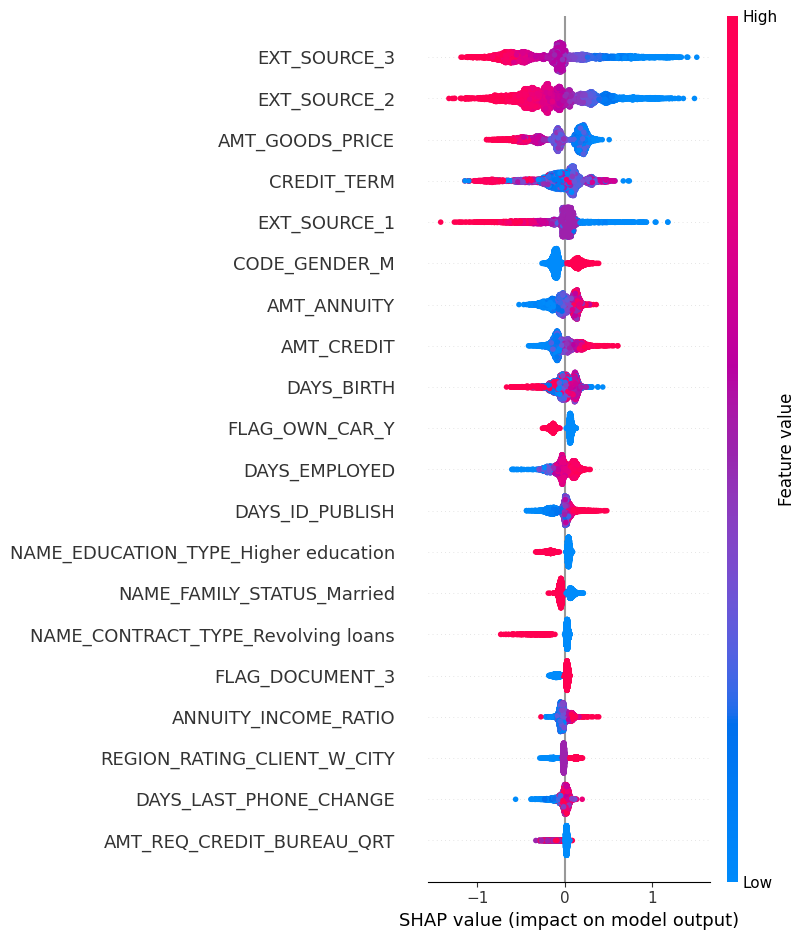

In [10]:
shap.summary_plot(shap_values, X_sample, max_display=20)

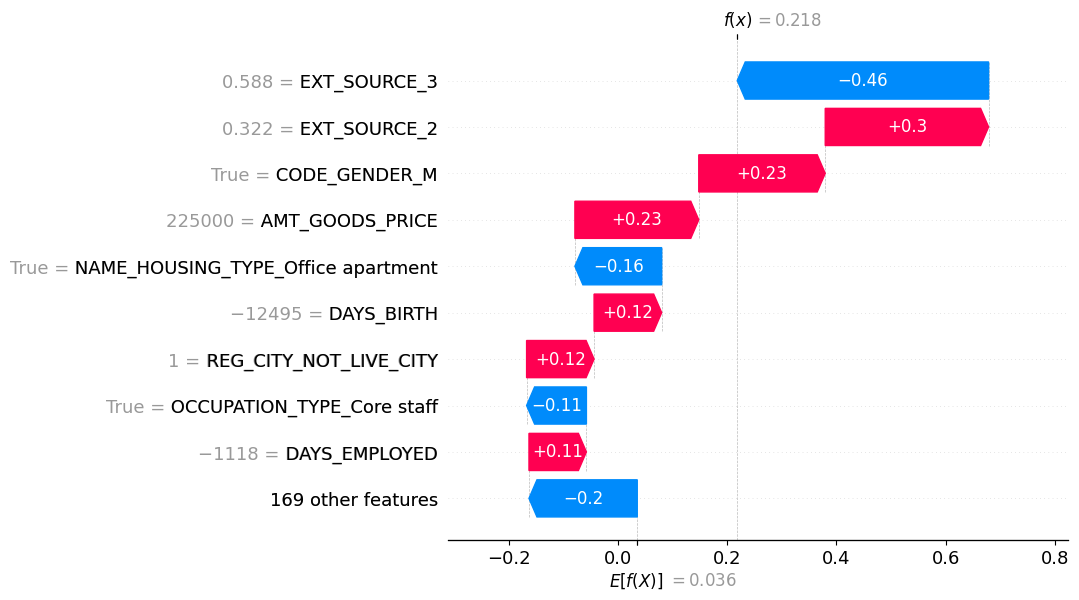

In [12]:
# Prendre le premier emprunteur du sample
sample = X_sample.iloc[[0]]

explainer_v2 = shap.Explainer(final_model)
shap_explanation = explainer_v2(sample)

shap.plots.waterfall(shap_explanation[0])

In [14]:
import pandas as pd
import pickle
import numpy as np

# Charger le test set Kaggle
test = pd.read_csv('./data/application_test.csv')
test_ids = test['SK_ID_CURR']

print(test.shape)

(48744, 121)
